In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split, KFold 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import accuracy_score 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense 
from tensorflow.keras.utils import to_categorical

In [23]:
df = pd.read_csv('your_file.csv')
print(df.head()) 

   Experience  Education  Age  Salary
0           1         12   22   25000
1           2         12   24   30000
2           3         14   26   38000
3           4         14   28   45000
4           5         15   30   52000


In [24]:
salary = df['Salary'] 
conditions = [ 
salary < 50000, 
(salary >= 50000) & (salary < 90000), 
salary >= 90000 
] 
choices = [0, 1, 2] 
df['SalaryClass'] = np.select(conditions, choices) 

In [25]:
X = df[['Experience', 'Education', 'Age']] 
y = df['SalaryClass']

In [26]:
X_train, X_test, y_train, y_test = train_test_split( 
X, y, test_size=0.2, random_state=42, stratify=y 
) 

In [27]:
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test) 

In [28]:
y_train_cat = to_categorical(y_train, num_classes=3) 
y_test_cat = to_categorical(y_test, num_classes=3) 

In [29]:
def build_model(): 
    model = Sequential([ 
        Dense(16, activation='relu', input_shape=(3,)), 
        Dense(8, activation='relu'), 
        Dense(3, activation='softmax') 
    ]) 
    model.compile(optimizer='adam', 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy']) 
    return model    

In [30]:
epochs_list = [50, 100] 
batch_list = [8, 16]  
best_accuracy = 0 
best_params = {}  
kfold = KFold(n_splits=5, shuffle=True, random_state=42) 
 
for epoch in epochs_list: 
    for batch in batch_list: 
        fold_accuracies = [] 
 
        for train_idx, val_idx in kfold.split(X_train_scaled): 
            X_fold_train = X_train_scaled[train_idx] 
            X_fold_val = X_train_scaled[val_idx] 
            y_fold_train = y_train_cat[train_idx] 
            y_fold_val = y_train_cat[val_idx] 
 
            model = build_model() 
            model.fit(X_fold_train, y_fold_train, 
                      epochs=epoch, 
                      batch_size=batch, 
                      verbose=0) 
 
            val_loss, val_acc = model.evaluate(X_fold_val, y_fold_val, verbose=0) 
            fold_accuracies.append(val_acc) 
 
        avg_acc = np.mean(fold_accuracies) 
 
        if avg_acc > best_accuracy: 
            best_accuracy = avg_acc 
            best_params = {'epochs': epoch, 'batch_size': batch}

e:\anaconda3\envs\ml_lab\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
print("Best Parameters:", best_params) 
print("Best Cross Validation Accuracy:", best_accuracy) 

Best Parameters: {'epochs': 100, 'batch_size': 16}
Best Cross Validation Accuracy: 0.8428571462631226


In [32]:
final_model = build_model() 
final_model.fit(X_train_scaled, y_train_cat, 
                epochs=best_params['epochs'], 
                batch_size=best_params['batch_size'], 
                verbose=1)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.1613 - loss: 1.1714 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1613 - loss: 1.1629
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1613 - loss: 1.1550
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1613 - loss: 1.1468
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1613 - loss: 1.1401
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1613 - loss: 1.1331
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1613 - loss: 1.1268
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1613 - loss: 1.1209
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1613 - loss: 1.1149
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2258 - loss: 1.1103
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2903 - loss: 1.1047
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2903 - l

In [33]:
y_pred_prob = final_model.predict(X_test_scaled) 
y_pred = np.argmax(y_pred_prob, axis=1) 
 
test_accuracy = accuracy_score(y_test, y_pred) 
print("Test Accuracy:", test_accuracy) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Test Accuracy: 0.875


In [34]:
history = final_model.fit(
    X_train_scaled, y_train_cat,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    validation_split=0.2,
    verbose=1
)

Epoch 1/100


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.9167 - loss: 0.4533 - val_accuracy: 1.0000 - val_loss: 0.2372
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9167 - loss: 0.4477 - val_accuracy: 1.0000 - val_loss: 0.2306
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9167 - loss: 0.4418 - val_accuracy: 1.0000 - val_loss: 0.2241
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9167 - loss: 0.4365 - val_accuracy: 1.0000 - val_loss: 0.2183
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9167 - loss: 0.4307 - val_accuracy: 1.0000 - val_loss: 0.2125
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9167 - loss: 0.4255 - val_accuracy: 1.0000 - val_loss: 0.2071
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9167 - loss: 0.4206 - val_accuracy: 1.0000 - val_loss: 0.2019
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9167 - loss: 0.4155 - val_accuracy: 1.0000 - val_loss: 0.1974
Epo

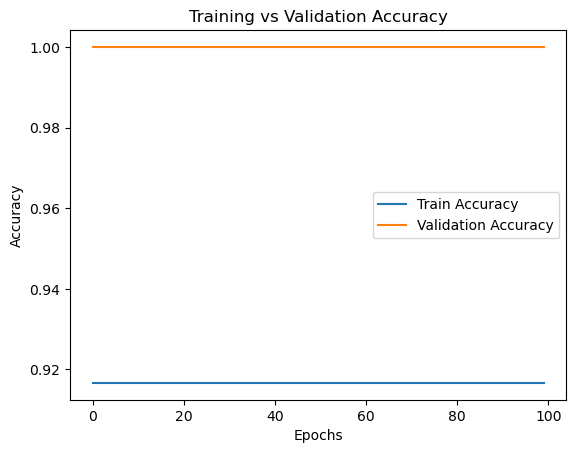

In [38]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

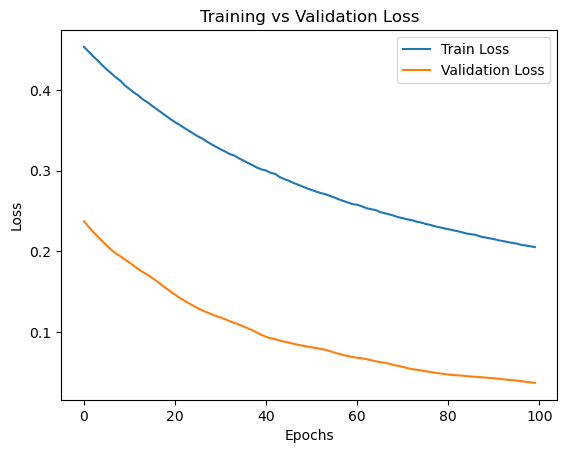

In [39]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

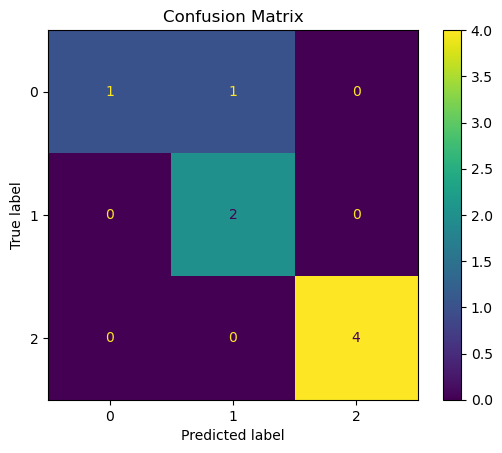

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [41]:
print("Predicted Probabilities:\n", y_pred_prob[:5])

Predicted Probabilities:
 [[0.04997393 0.17614685 0.7738792 ]
 [0.01349695 0.08777114 0.898732  ]
 [0.4393752  0.51098406 0.04964075]
 [0.17527199 0.5711684  0.25355953]
 [0.5238898  0.4299017  0.04620856]]
